# A tutorial on PyMC

**Day 2, 12:00 — 60 minutes.** Alexander Fengler.

<img src="../../images/logos/pymc-logo.png" alt="PyMC logo"
     style="display:block; margin:0.5rem auto 1.5rem auto; width:240px">

PyMC lets you write a generative model in Python and get a posterior back.
This session builds that from the bottom: what a distribution object *is*,
what a model is made of, what `pm.sample()` actually hands you, and how to
look at it. We finish by writing a regression twice — once by hand, once in
one line with **bambi** — so you can see exactly what the shortcut is doing.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import bambi as bmb
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-pymc"))
rng = np.random.default_rng(RANDOM_SEED)

print("pymc", pm.__version__, "| arviz", az.__version__, "| bambi", bmb.__version__)

pymc 6.2.0 | arviz 1.2.0 | bambi 0.19.0


## Where PyMC comes from, and what it actually does

**PyMC is a probabilistic programming library.** You write down a generative
model — priors, then how data arise from them — and the library works out how
to condition that model on observed data. You never write a sampler.

### A very short history

PyMC has been developed since the mid-2000s, making it one of the older
projects in this space. The version most people met, **PyMC3**, was built on
**Theano** — an early symbolic-computation and automatic-differentiation
library from the deep-learning world. When Theano's upstream development wound
down, the PyMC team took over maintenance and eventually forked it into what
is now **PyTensor**, the engine under PyMC 5 and 6. That is an unusual
situation worth knowing about: a statistics library ended up maintaining its
own tensor and autodiff engine.

### The idea it shares with deep learning frameworks

When you write

```python
with pm.Model():
    mu = pm.Normal("mu", 0, 1)
    pm.Normal("y", mu=mu, sigma=1, observed=data)
```

nothing is computed yet. You are **building a graph** — a symbolic description
of how quantities depend on one another. PyTensor can then

1. **differentiate** that graph automatically, and
2. **compile** it to fast code (C, numba, or JAX).

If you have used PyTorch or JAX, this is the same core machinery: define a
computation graph, get gradients for free, compile it. What differs is what
the gradients are *for*. In deep learning you differentiate a **loss** and
descend it to a point estimate. Here you differentiate the **log-posterior**
and hand those gradients to a sampler, which uses them to *explore* the
posterior rather than to minimise anything. Same engine, different
destination: the output is a distribution over parameters, not a fitted value.

### The neighbourhood

| | what it is |
|---|---|
| **PyMC** | the modelling library — this session |
| **PyTensor** | the graph / autodiff / compile engine underneath |
| **ArviZ** | diagnostics and plotting for whatever you fitted |
| **bambi** | common regressions as formulas; builds the PyMC model for you |
| **nutpie** | a fast NUTS implementation you can swap in |
| **HSSM** | sequential-sampling models on top of PyMC — Day 3, 09:30 |

Comparable tools elsewhere: **Stan** (its own language, very mature),
**NumPyro** and **Pyro** (on JAX and PyTorch), **Turing.jl** (Julia). The
concepts transfer directly; the syntax does not.

<details class="sbi-tip" open>
<summary>💡 <b>The one sentence to keep</b></summary>

You describe the *generative story*; the library turns it into a
differentiable graph and samples the posterior for you.

</details>

<details class="sbi-warn" open>
<summary>⚠️ <b>Read this before you copy code off the internet</b></summary>

**ArviZ v1.0 (May 2026) was a breaking release.** `az.plot_posterior`,
`az.plot_ppc`, `az.plot_density`, `az.plot_kde` and `az.waic` **no longer
exist**. `az.plot_trace` still exists but now draws *traces only*. The default
credible interval changed from a 94% HDI to an **89% ETI**, so even printed
numbers differ from older material.

Most PyMC tutorials online — including large parts of PyMC's own example
gallery — predate this. If a snippet errors with `AttributeError` on an
`az.plot_*` function, that is why. The pinned `tutorials/uv.lock` guarantees
you are on the versions this notebook was written against.

</details>

In [2]:
print("az.plot_posterior exists?", hasattr(az, "plot_posterior"))
print("az.waic exists?          ", hasattr(az, "waic"))
print("use instead: az.plot_dist, az.plot_ppc_dist, az.plot_trace_dist, az.loo")

az.plot_posterior exists? False
az.waic exists?           False
use instead: az.plot_dist, az.plot_ppc_dist, az.plot_trace_dist, az.loo


## 1. What is a PyMC distribution?
### Standalone

This is the piece most tutorials skip, and it is the source of most early
confusion. A PyMC distribution is used in **two different ways**, and they
behave differently.

In [3]:
# (a) Standalone — a distribution object, not attached to anything.
standalone = pm.Normal.dist(mu=0.0, sigma=1.0)
print("type:", type(standalone).__name__)
print("5 draws:", pm.draw(standalone, draws=5, random_seed=RANDOM_SEED).round(3))

# You can also evaluate the log-likelihood (logp) at specific values:
values = np.array([0.0, 1.0, -1.0])
logps = pm.logp(standalone, values).eval()
print("logp at [0.0, 1.0, -1.0]:", np.round(logps, 3))

type: TensorVariable
5 draws: [-0.241 -0.112 -0.713  0.371  0.275]
logp at [0.0, 1.0, -1.0]: [-0.919 -1.419 -1.419]


`pm.Normal.dist(...)` gives you a standalone *distribution* object. It doesn't belong to any model. Use it whenever you want a distribution 

1. as a value
2. inside another distribution
3. as a prior you are inspecting
4. just to simulate from a named distribution

### Densities, not just draws

A distribution also knows its own log-density. This is the quantity every
sampler in this course is actually working with.

logp at 0: -0.9189  (= -0.5*log(2*pi) = -0.9189 )


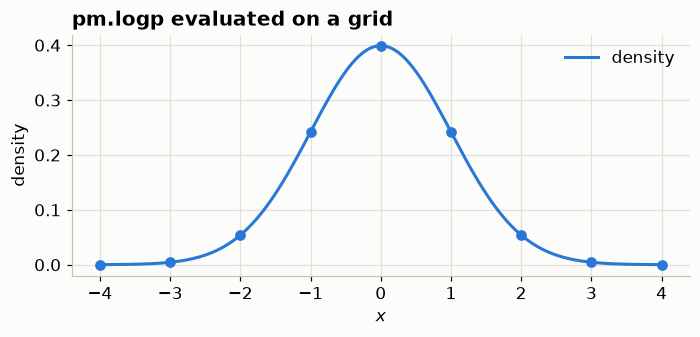

In [4]:
grid = np.linspace(-4, 4, 9)
logp = pm.logp(pm.Normal.dist(0.0, 1.0), grid).eval()

fig, ax = plt.subplots(figsize=(6.5, 3.2))
xs = np.linspace(-4, 4, 300)
ax.plot(xs, np.exp(pm.logp(pm.Normal.dist(0.0, 1.0), xs).eval()),
        color=S.PRIMARY, label="density")
ax.plot(grid, np.exp(logp), "o", color=S.PRIMARY, ms=6, ls="none")
ax.set(title="pm.logp evaluated on a grid", xlabel="$x$", ylabel="density")
ax.legend()
fig.tight_layout()

print("logp at 0:", float(pm.logp(pm.Normal.dist(0.0, 1.0), 0.0).eval()).__round__(4),
      " (= -0.5*log(2*pi) =", round(float(-0.5 * np.log(2 * np.pi)), 4), ")")

Now the second way:

### Distributions inside a PyMC model

In [5]:
# (b) Named, inside a model context — a random VARIABLE in a graph.
with pm.Model() as demo:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)

print("type:", type(mu).__name__)
print("model variables:", [v.name for v in demo.basic_RVs])

type: TensorVariable
model variables: ['mu']


Inside a `with pm.Model()` block, the same call **registers a node in a
graph**. The name is not decoration — it is the key you will use to get the
posterior back out. Two variables cannot share a name.

Try it outside a model context and PyMC tells you exactly what is wrong:

In [6]:
try:
    oops = pm.Normal("mu", 0.0, 1.0)
except TypeError as e:
    print("TypeError:", e)

TypeError: No model on context stack, which is needed to instantiate distributions. Add variable inside a 'with model:' block, or use the '.dist' syntax for a standalone distribution.


> **Poll:**  
What is the difference between `pm.Normal("x", 0, 1)` and `pm.Normal.dist(0, 1)`?  
- **A.** Nothing; `.dist()` is just shorthand.  
- **B.** `.dist()` is faster because it skips validation.  
- **C.** The named form registers a variable in the enclosing model; `.dist()` returns a free-standing distribution belonging to no model.  
- **D.** `.dist()` can only be used for priors.

<details>
<summary>Answer</summary>

**C.** The named form needs a model context and will raise without one. The
`.dist()` form is a value you can draw from, take the logp of, or nest inside
another distribution — which is exactly how you build custom likelihoods and
mixtures.

</details>

## 2. A first model, and what `pm.sample()` returns

The smallest interesting problem: we observe noisy measurements of an unknown
mean and want the posterior over that mean. Written out,

$$
\mu \sim \text{Normal}(0,\ 10), \qquad
\sigma \sim \text{HalfNormal}(5), \qquad
y_i \mid \mu, \sigma \;\sim\; \text{Normal}(\mu,\ \sigma)
\quad \text{for } i = 1,\dots,60 .
$$

The first two lines are the **prior**, the third is the **likelihood**. The
code below is a line-for-line transcription of exactly that.

In [7]:
TRUE_MU, TRUE_SIGMA, N = 2.5, 1.5, 60
y_obs = rng.normal(TRUE_MU, TRUE_SIGMA, N)

with pm.Model() as first_model:
    mu = pm.Normal("mu", mu=0.0, sigma=10.0)      # prior
    sigma = pm.HalfNormal("sigma", sigma=5.0)     # prior
    pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)   # likelihood

    idata = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                      nuts_sampler="pymc", progressbar=False,
                      random_seed=RANDOM_SEED)

print(type(idata))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


<class 'xarray.core.datatree.DataTree'>


### Look at the model before you look at the answer

`pm.model_to_graphviz` draws the graph PyMC built. Shaded nodes are observed,
open nodes are things being estimated, and the box is the *plate* — the 60
observations that share the same `mu` and `sigma`. Reading this before
sampling catches an entire class of mistake: a prior you forgot to connect, a
variable with the wrong shape, an observation that is not actually observed.

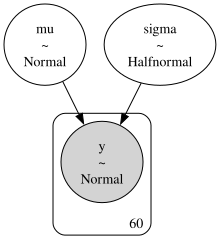

In [8]:
try:
    graph = pm.model_to_graphviz(first_model)
except Exception as exc:                      # graphviz needs the `dot` BINARY
    print(f"graphviz unavailable ({type(exc).__name__}); "
          "showing the mermaid description instead")
    print(pm.model_to_mermaid(first_model))
    graph = None
graph

<details class="sbi-note">
<summary>📝 <b>If that cell printed text instead of a picture</b></summary>

`model_to_graphviz` needs the **`dot` system binary**, not just the Python
`graphviz` package — `brew install graphviz` / `apt install graphviz` /
`conda install graphviz`. PyMC 6 also ships `pm.model_to_mermaid()`, which is
pure text and always available, which is what the fallback prints.

</details>

<details class="sbi-key" open>
<summary>🔑 <b><code>pm.sample()</code> returns an <code>xarray.DataTree</code></b></summary>

In PyMC 6 this is **not** an `arviz.InferenceData` any more. `InferenceData`
still exists as a compatibility shim that warns and hands you a `DataTree`.
The API docstring on the website still says "InferenceData" — the code
disagrees, and the code wins.

</details>

A `DataTree` is a tree of labelled groups. Look at what is in it:

In [9]:
idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           mu       (chain, draw) float64 32kB 2.452 2.588 2.308 ... 2.604 2.055 2.186
│           sigma    (chain, draw) float64 32kB 1.287 1.298 1.144 ... 1.457 1.212 1.3
│       Attributes:
│           created_at:                 2026-07-27T19:34:07.161253+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              0.38241100311279297
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│       Data variables: (12/18)
│           energy                 (chain, draw) float64 32kB 103.2 104.9 ... 106.4
│           energy_error           (chain, draw) float64 32kB -0.02741 ... -0.9951
│           step_size_bar          (chain, draw) float64 32kB 1.196 1.196 ... 1.124
│           index_in_trajectory    (chain, draw) int64 32kB -1 -3 1 1 -3 ... -1 -1 2 1
│           smallest_eigval        (chain, draw) float64 32kB nan nan nan ... nan nan
│           n_steps                (chain, draw) float64 32kB 1.0 3.0 3.0 ... 3.0 1.0
│           ...                     ...
│           largest_eigval         (chain, draw) float64 32kB nan nan nan ... nan nan
│           reached_max_treedepth  (chain, draw) bool 4kB False False ... False False
│           step_size              (chain, draw) float64 32kB 1.135 1.135 ... 1.061
│           max_energy_error       (chain, draw) float64 32kB -0.02741 ... -0.9951
│           perf_counter_start     (chain, draw) float64 32kB 1.86e+06 ... 1.86e+06
│           process_time_diff      (chain, draw) float64 32kB 2.7e-05 ... 1.5e-05
│       Attributes:
│           created_at:                 2026-07-27T19:34:07.165557+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              0.38241100311279297
│           tuning_steps:               1000
└── Group: /observed_data
        Dimensions:  (y_dim_0: 60)
        Coordinates:
          * y_dim_0  (y_dim_0) int64 480B 0 1 2 3 4 5 6 7 8 ... 52 53 54 55 56 57 58 59
        Data variables:
            y        (y_dim_0) float64 480B 2.587 2.781 4.849 ... 2.398 5.916 0.2535
        Attributes:
            created_at:                 2026-07-27T19:34:07.166835+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.2.0
            sample_dims:                []

In [10]:
list(idata.children)

['posterior', 'sample_stats', 'observed_data']

In [11]:

idata["posterior"].dataset

<xarray.DatasetView> Size: 72kB
Dimensions:  (chain: 4, draw: 1000)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    mu       (chain, draw) float64 32kB 2.452 2.588 2.308 ... 2.604 2.055 2.186
    sigma    (chain, draw) float64 32kB 1.287 1.298 1.144 ... 1.457 1.212 1.3
Attributes:
    created_at:                 2026-07-27T19:34:07.161253+00:00
    creation_library:           ArviZ
    creation_library_version:   1.2.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  6.2.0
    sample_dims:                ['chain', 'draw']
    sampling_time:              0.38241100311279297
    tuning_steps:               1000

### Data Structures that can cause confusion

`idata.posterior` is a **DataTree node**, not a `Dataset`. Most `xarray`
operations you want live on the `Dataset`, so reach through `.dataset`:

In [12]:
print("idata.posterior       ->", type(idata.posterior).__name__)
print("idata.posterior.dataset ->", type(idata.posterior.dataset).__name__)
print("idata.posterior['mu'] ->", type(idata.posterior["mu"]).__name__)
print()

post = idata.posterior.dataset
print("shape (chain, draw):", post["mu"].shape)
print("posterior mean mu = %.3f   (true %.1f)" % (post["mu"].values.mean(), TRUE_MU))
print("posterior mean sigma = %.3f (true %.1f)" % (post["sigma"].values.mean(), TRUE_SIGMA))

idata.posterior       -> DataTree
idata.posterior.dataset -> DatasetView
idata.posterior['mu'] -> DataArray

shape (chain, draw): (4, 1000)
posterior mean mu = 2.497   (true 2.5)
posterior mean sigma = 1.278 (true 1.5)


### What you get once you are on the `Dataset`

It is worth being concrete about *why* that reach-through matters, because
"use xarray" is advice people nod at and then ignore. The payoff is that the
array carries its **dimension names** — `chain`, `draw` — so you stop writing
`axis=0` and start writing what you mean.

In [13]:
# 1. REDUCE BY NAME. No axis numbers, and it applies to every variable at once.
print(post.mean(dim=["chain", "draw"]))

<xarray.Dataset> Size: 16B
Dimensions:  ()
Data variables:
    mu       float64 8B 2.497
    sigma    float64 8B 1.278
Attributes:
    created_at:                 2026-07-27T19:34:07.161253+00:00
    creation_library:           ArviZ
    creation_library_version:   1.2.0
    creation_library_language:  Python
    inference_library:          pymc
    inference_library_version:  6.2.0
    sample_dims:                ['chain', 'draw']
    sampling_time:              0.38241100311279297
    tuning_steps:               1000


In [14]:
# 2. SELECT BY LABEL. `sel` uses coordinate values, `isel` uses positions.
#    "chain 2, last five draws" is one expression rather than a slice puzzle.
print("chain 2, last 5 draws of mu:",
      post["mu"].sel(chain=2).isel(draw=slice(-5, None)).values.round(3))

chain 2, last 5 draws of mu: [2.866 2.404 2.514 2.515 2.795]


In [15]:
# 3. PER-CHAIN MEANS
print("\nmean of mu within each chain:")
print(post["mu"].mean(dim="draw").to_series().round(3).to_string())


mean of mu within each chain:
chain
0    2.489
1    2.497
2    2.500
3    2.501


In [16]:
# 4. DERIVED QUANTITIES ARE FREE, and stay labelled. Any function of the
#    parameters has a posterior too, and you get it by transforming the draws --
#    no re-fitting, no delta method, no reshaping.
derived = post.assign(
    cv=post["sigma"] / post["mu"],            # coefficient of variation
    z_score=(3.0 - post["mu"]) / post["sigma"],  # how extreme is y = 3?
)
print(az.summary(derived, var_names=["cv", "z_score"], kind="stats").to_string())

         mean    sd eti89_lb eti89_ub
cv       0.51  0.06     0.43     0.62
z_score   0.4  0.14     0.19     0.62


In [17]:
# 5. QUANTILES ALONG NAMED DIMS. `az.summary` is the convenient path, but the
#    raw xarray call is there when you want something it does not offer.
print(post.quantile([0.055, 0.5, 0.945], dim=["chain", "draw"])
          .to_dataframe().round(3).to_string())

             mu  sigma
quantile              
0.055     2.233  1.098
0.500     2.498  1.270
0.945     2.763  1.481


Point 3 is the one to remember. The posterior over $\sigma/\mu$ was never
something we asked the sampler for — we pushed the draws through a function
and read off the answer. **Any** quantity you can compute from the parameters
has a posterior, and this is how you get it. That is a genuine advantage of
sampling over optimisation, where propagating uncertainty through a nonlinear
transform is real work.

The `sample_stats` group is where the sampler records what it did. This is
where divergences live — we will make use of it during out Day 3 tutorials.

In [18]:
print(sorted(idata["sample_stats"].dataset.data_vars))

['acceptance_rate', 'divergences', 'diverging', 'energy', 'energy_error', 'index_in_trajectory', 'largest_eigval', 'lp', 'max_energy_error', 'n_steps', 'perf_counter_diff', 'perf_counter_start', 'process_time_diff', 'reached_max_treedepth', 'smallest_eigval', 'step_size', 'step_size_bar', 'tree_depth']


### `coords` and `dims` — naming your own dimensions

Everything above worked because `chain` and `draw` are *named* dimensions.
**You can name your parameters' dimensions too**, and once a model has more
than one of anything — one drift per condition, one intercept per participant
— you will want to.

The alternative is `shape=`, which works but leaves the result anonymous.
Compare. Three group means, three observations each:

In [19]:
y_grp = rng.normal([1.0, 2.0, 3.0], 1.0, size=(40, 3))

# (a) shape= — correct, but the posterior does not know what the axis MEANS
with pm.Model() as m_shape:
    mu_s = pm.Normal("mu", 0.0, 5.0, shape=3)
    pm.Normal("y", mu=mu_s, sigma=1.0, observed=y_grp)
    idata_shape = pm.sample(300, tune=300, chains=2, cores=1, nuts_sampler="pymc",
                            progressbar=False, random_seed=RANDOM_SEED)

print("dimension names:", list(idata_shape.posterior.dataset["mu"].dims))
print(az.summary(idata_shape, kind="stats").to_string())

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu]


Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


dimension names: ['chain', 'draw', 'mu_dim_0']
       mean    sd eti89_lb eti89_ub
mu[0]  0.93  0.16     0.69      1.2
mu[1]   1.9  0.16      1.7      2.2
mu[2]     3  0.17      2.8      3.3


In [20]:
# (b) coords + dims — the model carries the labels, and so does everything after
COORDS = {"condition": ["low", "med", "high"]}

with pm.Model(coords=COORDS) as m_dims:
    mu_d = pm.Normal("mu", 0.0, 5.0, dims="condition")
    pm.Normal("y", mu=mu_d, sigma=1.0, observed=y_grp)
    idata_dims = pm.sample(300, tune=300, chains=2, cores=1, nuts_sampler="pymc",
                           progressbar=False, random_seed=RANDOM_SEED)

print("dimension names:", list(idata_dims.posterior.dataset["mu"].dims))
print(az.summary(idata_dims, kind="stats").to_string())

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu]


Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


dimension names: ['chain', 'draw', 'condition']
          mean    sd eti89_lb eti89_ub
mu[low]   0.93  0.16     0.69      1.2
mu[med]    1.9  0.16      1.7      2.2
mu[high]     3  0.17      2.8      3.3


`mu[0], mu[1], mu[2]` became `mu[low], mu[med], mu[high]`. That is not
cosmetic — the labels are now data you can compute with:

In [21]:
post_d = idata_dims.posterior.dataset
print("the 'high' condition only:",
      round(float(post_d["mu"].sel(condition="high").mean()), 3))

# A contrast, by name rather than by remembering which integer is which.
contrast = post_d["mu"].sel(condition="high") - post_d["mu"].sel(condition="low")
print(f"high - low = {float(contrast.mean()):.3f} "
      f"[{float(contrast.quantile(0.055)):.3f}, {float(contrast.quantile(0.945)):.3f}]")

the 'high' condition only: 3.033
high - low = 2.100 [1.717, 2.497]


<details class="sbi-tip" open>
<summary>💡 <b>Why this matters more than it looks</b></summary>

Three reasons to reach for `dims` from the start:

1. **You stop counting indices.** `sel(condition="high")` cannot silently
   become the wrong group the way `[2]` can when you reorder a list.
2. **Plots and tables label themselves.** `az.summary`, `az.plot_forest` and
   the rest read the coordinate values, so figures arrive with real names on
   them instead of `mu[0]`.
3. **It is what the libraries above PyMC do anyway.** Every posterior you see
   for the rest of this course is labelled this way — at 14:30 you will write
   `pm.Model(coords=...)` with `dims="coherence"` for a drift rate per
   coherence level, and tomorrow HSSM will hand you back
   `a_C(cond)[hard]` without you asking. Recognising where those labels come
   from is the point of this section.

The cost is one dictionary. `pm.Model(coords={"condition": [...]})` declares
the labels once; `dims="condition"` on a variable adopts them and sets its
shape for you — note we never wrote `shape=3` in the second model.

</details>

## 3. Looking at a posterior

In [22]:
print(az.summary(idata, kind="stats").to_string())

      mean    sd eti89_lb eti89_ub
mu     2.5  0.17      2.2      2.8
sigma  1.3  0.12      1.1      1.5


Note the interval columns: **89% ETI**, not the 94% HDI you may remember.
You can ask for something else explicitly:

In [23]:
print(az.summary(idata, kind="stats", ci_prob=0.94, ci_kind="hdi").to_string())

      mean    sd hdi94_lb hdi94_ub
mu     2.5  0.17      2.2      2.8
sigma  1.3  0.12      1.1      1.5


The standard first look is `plot_trace_dist` — marginals on the left, traces
on the right.

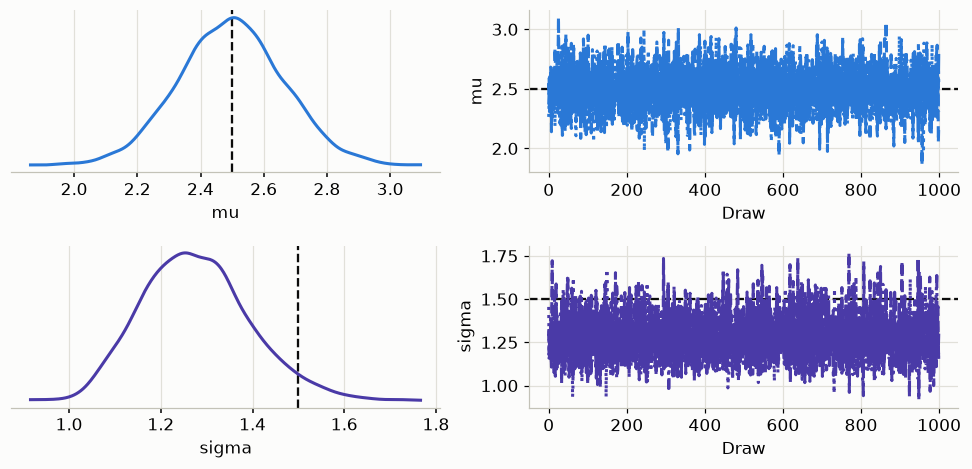

In [24]:
trace = az.plot_trace_dist(idata, combined=True)
plt.gcf().set_size_inches(9, 4.4)

# ArviZ returns a PlotCollection rather than an array of Axes. `get_target`
# takes the variable and the panel's coordinates and hands back the Axes, which
# is how we draw anything ArviZ does not — here, the values we generated from.
# The marginal panel wants a VERTICAL truth line (the x axis is the parameter);
# the trace panel wants a HORIZONTAL one (the y axis is the parameter).
for var, truth in [("mu", TRUE_MU), ("sigma", TRUE_SIGMA)]:
    S.truth_line(trace.get_target(var, {"column": "dist"}), truth, axis="x")
    S.truth_line(trace.get_target(var, {"column": "trace"}), truth, axis="y")

plt.tight_layout()

On the **left** it tells you whether the posterior actually covers the value
that generated the data. On the **right** it tells you whether the chains are
wandering *around* that value rather than drifting toward it — a trace that
approaches the truth from one side and keeps going is a chain that has not
converged.

And the joint, `az.plot_pair` gives the marginals on the diagonal 
and the joint off it. `marginal_kind="kde"` smooths the marginals 
into densities rather than histograms.

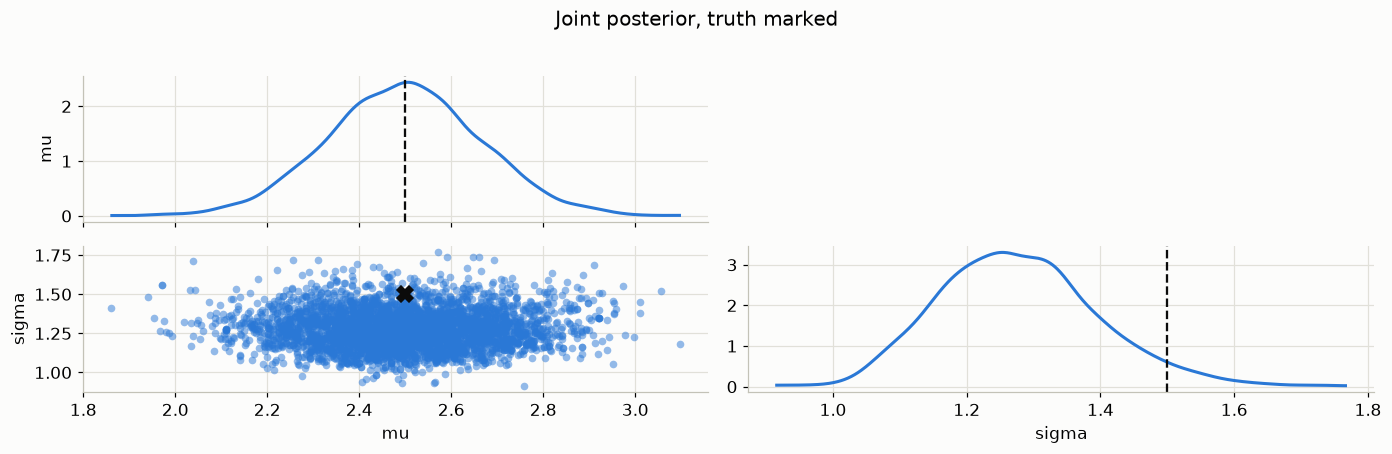

In [25]:
pair = az.plot_pair(idata, var_names=["mu", "sigma"],
                    marginal=True, marginal_kind="kde")

# ArviZ returns a PlotMatrix, not a bare matplotlib figure. `get_target` hands
# back the Axes for a given panel, which is how we add anything ArviZ does not
# draw itself — here, the true values used to generate the data.
S.truth_point(pair.get_target("mu", {}, "sigma", {}), TRUE_MU, TRUE_SIGMA)
for var, truth in [("mu", TRUE_MU), ("sigma", TRUE_SIGMA)]:
    pair.get_target(var, {}).axvline(truth, color=S.TRUTH, ls="--", lw=1.5)

plt.gcf().suptitle("Joint posterior, truth marked", y=1.02)
plt.tight_layout()

<details class="sbi-note">
<summary>📝 <b>Marking ground truth is a habit worth forming</b></summary>

ArviZ has no "true value" argument, because in real analyses there is no true
value to pass — you only have this when you generated the data yourself. That
is exactly why it is worth doing whenever you *can*: a plot with the truth on
it answers "did this work?" in one glance, and simulating data with known
parameters is the cheapest way to check a model before trusting it on real
data. We use the same trick throughout Day 2 and Day 3.

</details>

`mu` and `sigma` are close to independent here — a round blob, and the truth
sits inside it. Remember what this looks like; by 15:00 today you will be
looking at one that is not.

### What conditioning on data actually did

Two pictures make the whole point of Bayesian inference concrete. Both compare
*before seeing the data* with *after*.

**Prior to posterior** is contraction in **parameter** space: the prior says
what we were willing to believe, the posterior says what survives contact with
60 observations.

Sampling: [mu, sigma, y]


sd(mu): prior  10.032 -> posterior  0.166   (60x narrower)
sd(sigma): prior   2.942 -> posterior  0.120   (25x narrower)


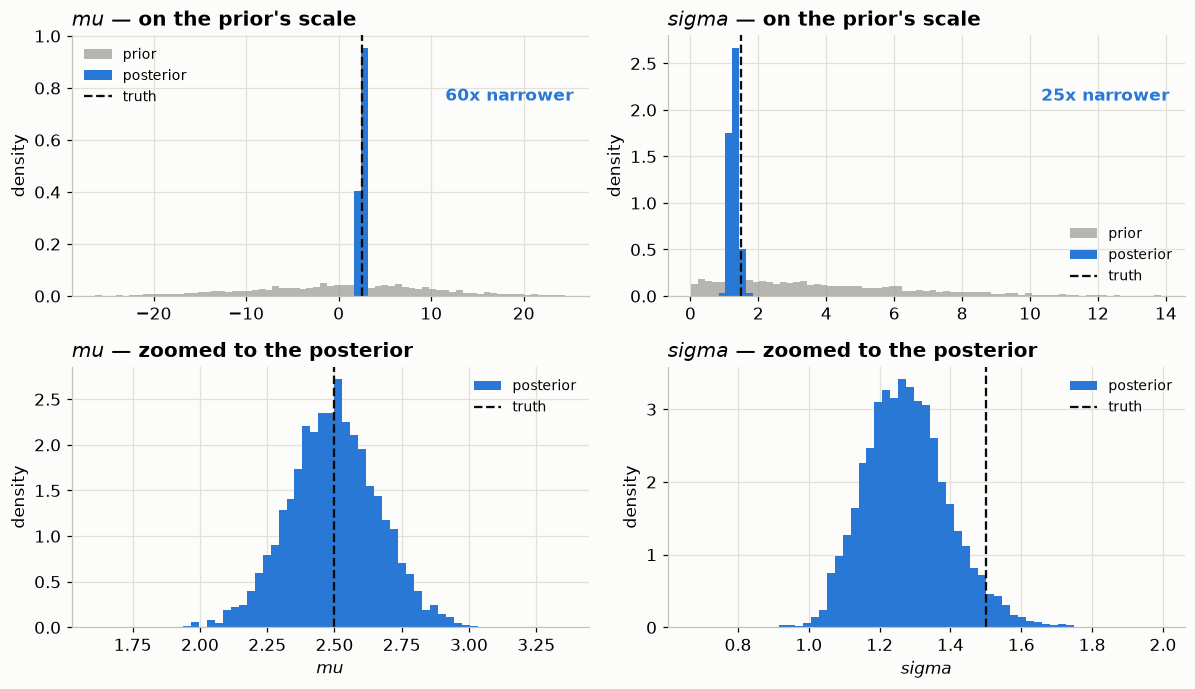

In [26]:
with first_model:
    prior = pm.sample_prior_predictive(draws=2000, random_seed=RANDOM_SEED)

# Two rows: the top shows the contraction, the bottom zooms in so the posterior
# is more than a spike. Both are needed — the first is the message, the second
# is the shape.
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4))
for col, (var, truth) in enumerate([("mu", TRUE_MU), ("sigma", TRUE_SIGMA)]):
    pri = prior["prior"].dataset[var].values.ravel()
    pos = post[var].values.ravel()

    # top: full prior range
    ax = axes[0, col]
    lo, hi = np.percentile(pri, [0.5, 99.5])
    bins = np.linspace(lo, hi, 70)
    ax.hist(pri, bins=bins, density=True, color=S.MUTED, alpha=0.6, label="prior")
    ax.hist(pos, bins=bins, density=True, color=S.PRIMARY, label="posterior")
    S.truth_line(ax, truth, axis="x")
    ax.set(title=f"${var}$ — on the prior's scale", ylabel="density")
    ax.legend(fontsize=9)

    # bottom: zoomed to the posterior
    ax = axes[1, col]
    zlo, zhi = np.percentile(pos, [0.1, 99.9])
    pad = 0.35 * (zhi - zlo)
    zbins = np.linspace(zlo - pad, zhi + pad, 60)
    ax.hist(pos, bins=zbins, density=True, color=S.PRIMARY, label="posterior")
    S.truth_line(ax, truth, axis="x")
    ax.set(title=f"${var}$ — zoomed to the posterior", xlabel=f"${var}$",
           ylabel="density")
    ax.legend(fontsize=9)

    shrink = pri.std() / pos.std()
    axes[0, col].annotate(f"{shrink:.0f}x narrower", xy=(0.97, 0.75),
                          xycoords="axes fraction", ha="right",
                          color=S.PRIMARY, fontweight="bold")
fig.tight_layout()

for var in ["mu", "sigma"]:
    pri = prior["prior"].dataset[var].values.ravel()
    pos = post[var].values.ravel()
    print(f"sd({var}): prior {pri.std():7.3f} -> posterior {pos.std():6.3f}"
          f"   ({pri.std()/pos.std():.0f}x narrower)")

The posterior is dramatically narrower than the prior. That narrowing *is* the
information the data carried — and it is why "what is your prior?" and "how
wide is it?" are really the same question.

Look at the bottom-right panel before moving on: the true $\sigma = 1.5$ sits
in the **right tail** of its posterior, not in the middle. With 60
observations that is ordinary sampling variability, not a bug — a 89%
interval misses the truth roughly 11% of the time, by construction. Being
calibrated does not mean being right every time, and a posterior that always
covered the truth dead-centre would be a suspiciously overconfident one.

**Prior predictive to posterior predictive** is the same story in **data**
space: what datasets did the model consider plausible before and after?

Sampling: [y]


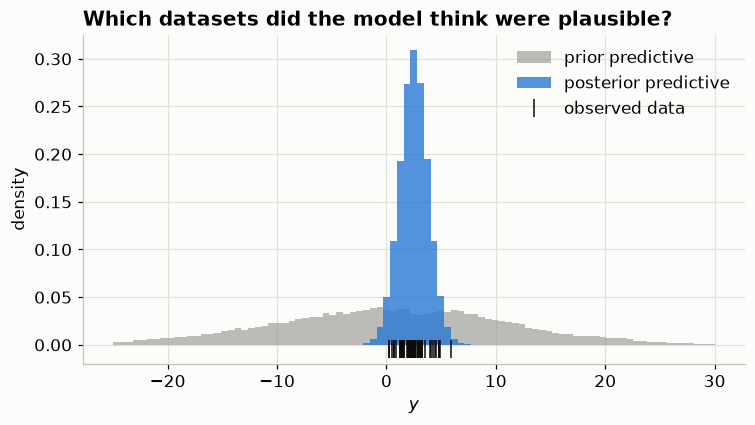

In [27]:
with first_model:
    ppc = pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED,
                                         progressbar=False)

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(-25, 30, 90)
ax.hist(prior["prior_predictive"].dataset["y"].values.ravel(), bins=bins,
        density=True, color=S.MUTED, alpha=0.55, label="prior predictive")
ax.hist(ppc["posterior_predictive"].dataset["y"].values.ravel(), bins=bins,
        density=True, color=S.PRIMARY, alpha=0.8, label="posterior predictive")
ax.plot(y_obs, np.full_like(y_obs, -0.004), "|", color=S.TRUTH, ms=12,
        label="observed data")
ax.set(title="Which datasets did the model think were plausible?",
       xlabel="$y$", ylabel="density")
ax.legend()
fig.tight_layout()

Before seeing anything, the model was prepared for data anywhere across a very
wide range — that is the `Normal(0, 10)` prior on `mu` talking. Afterwards it
predicts data that look like what we actually observed.

<details class="sbi-tip">
<summary>💡 <b>These are two different checks, and both are worth running</b></summary>

The **prior predictive** is checked *before* fitting and asks "is my model
capable of producing data like mine at all?" The **posterior predictive** is
checked *after* and asks "having fitted, can it reproduce what I saw?" A model
can pass the second and still have had an absurd prior — which is why the
first is not optional.

</details>

### Exercise 1

Re-fit `first_model` with a deliberately bad prior on `mu` — say
`pm.Normal("mu", 20, 0.5)` — and compare the posterior mean to the truth.
How much does 60 data points overcome a confidently wrong prior?

<details>
<summary>Solution</summary>

```python
with pm.Model():
    mu = pm.Normal("mu", 20.0, 0.5)          # confidently wrong
    sigma = pm.HalfNormal("sigma", 5.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)
    bad = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                    nuts_sampler="pymc", progressbar=False,
                    random_seed=RANDOM_SEED)
print(az.summary(bad, kind="stats").to_string())
```

The posterior lands between the prior and the data, much nearer the prior than
you might like — a `sigma=0.5` prior is worth a lot of observations. The
lesson is not "priors are dangerous" but "a prior is a claim, and you should
be able to defend its width as readily as its centre."

</details>

### Exercise 2

The Normal was an example, not the point. The machinery is identical for any
distribution PyMC knows. Fit a **Gamma**:

$$
\alpha \sim \text{HalfNormal}(5), \qquad
\beta \sim \text{HalfNormal}(5), \qquad
y_i \mid \alpha, \beta \;\sim\; \text{Gamma}(\alpha,\ \beta).
$$

Generate data from `pm.draw(pm.Gamma.dist(alpha=3.0, beta=2.0), 200)`, build
the model, sample it, and check that the posterior covers $\alpha = 3$ and
$\beta = 2$. Then plot the joint with `az.plot_pair` and mark the truth as we
did above.

<details>
<summary>Solution</summary>

```python
TRUE_ALPHA, TRUE_BETA = 3.0, 2.0
y_gamma = pm.draw(pm.Gamma.dist(alpha=TRUE_ALPHA, beta=TRUE_BETA), 200,
                  random_seed=RANDOM_SEED)

with pm.Model() as gamma_model:
    alpha = pm.HalfNormal("alpha", 5.0)
    beta = pm.HalfNormal("beta", 5.0)
    pm.Gamma("y", alpha=alpha, beta=beta, observed=y_gamma)
    idata_gamma = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                            nuts_sampler="pymc", progressbar=False,
                            random_seed=RANDOM_SEED)

print(az.summary(idata_gamma, kind="stats").to_string())

pair_g = az.plot_pair(idata_gamma, var_names=["alpha", "beta"],
                      marginal=True, marginal_kind="kde")
S.truth_point(pair_g.get_target("alpha", {}, "beta", {}), TRUE_ALPHA, TRUE_BETA)
```

Two things to notice. First, **nothing about the workflow changed** — swap the
distribution, keep everything else. Second, the joint posterior of `alpha` and
`beta` is *not* a round blob: they are strongly positively correlated, because
the Gamma's mean is $\alpha/\beta$ and the data pin the mean down much better
than they pin down either parameter alone. You have just found a parameter
trade-off, three hours before the session about them.

</details>

## 4. A regression, by hand

Same machinery, one step up:

$$
\beta_0 \sim \text{Normal}(0,\ 5), \qquad
\beta_1 \sim \text{Normal}(0,\ 5), \qquad
\sigma \sim \text{HalfNormal}(5),
$$
$$
y_i \mid \beta_0, \beta_1, \sigma \;\sim\;
\text{Normal}(\beta_0 + \beta_1 x_i,\ \sigma).
$$

Only the **mean** changed: it is now a function of a covariate instead of a
single number. Everything else — priors, likelihood, sampling, diagnostics —
is what you already saw.

In [28]:
# Generate Data
N_DATA = 120
rng = np.random.default_rng(RANDOM_SEED)

x = rng.normal(0.0, 1.0, N_DATA)
TRUE_INTERCEPT, TRUE_SLOPE, TRUE_NOISE = 1.0, 2.0, 0.8
y = TRUE_INTERCEPT + TRUE_SLOPE * x + rng.normal(0.0, TRUE_NOISE, N_DATA)
data = pd.DataFrame({"x": x, "y": y})

with pm.Model() as regression:
    # Priors
    intercept = pm.Normal("Intercept", 0.0, 5.0)
    slope = pm.Normal("x", 0.0, 5.0)
    sigma = pm.HalfNormal("sigma", 5.0)

    # Likelihood
    pm.Normal("y", mu=intercept + slope * data["x"].to_numpy(), sigma=sigma,
              observed=data["y"].to_numpy())

    # Sample
    idata_pymc = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                           nuts_sampler="pymc", progressbar=True,
                           random_seed=RANDOM_SEED)

print(az.summary(idata_pymc, kind="stats").to_string())
print(f"\ntruth: Intercept={TRUE_INTERCEPT}, x={TRUE_SLOPE}, sigma={TRUE_NOISE}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [Intercept, x, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


           mean     sd eti89_lb eti89_ub
Intercept  0.96  0.072     0.85      1.1
x           1.9  0.079      1.8      2.1
sigma      0.78  0.051      0.7     0.86

truth: Intercept=1.0, x=2.0, sigma=0.8


Four lines of model, and every line is a modelling decision you made on
purpose. That is the virtue of writing it out.

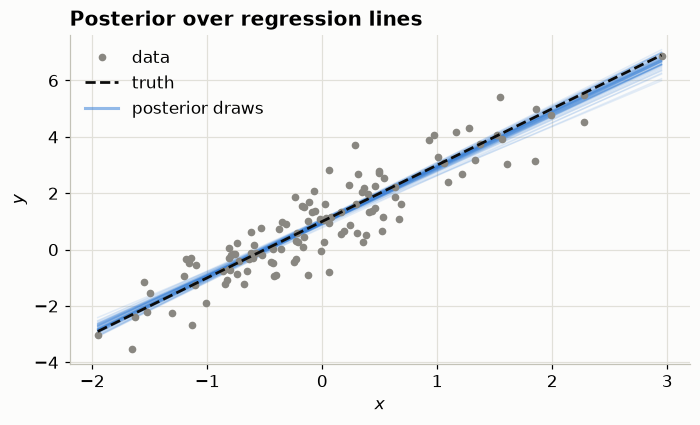

In [29]:
# Extract the posterior samples as an xarray dataset
post_p = idata_pymc.posterior.dataset

# Create a dense grid of x values spanning the observed data
xs = np.linspace(x.min(), x.max(), 100)

# Randomly sample 60 draws from the posterior (without replacement)
# This is for visualizing plausible regression lines
draws = rng.choice(post_p["Intercept"].values.size, 60, replace=False)

# Extract the sampled intercept and slope values (flatten to 1D)
ic = post_p["Intercept"].values.ravel()[draws]
sl = post_p["x"].values.ravel()[draws]

# Initialize the plot
fig, ax = plt.subplots(figsize=(6.5, 4))

# Plot 60 regression lines corresponding to random posterior draws
# These demonstrate plausible regression solutions the model considers likely
for i, s in zip(ic, sl):
    ax.plot(xs, i + s * xs, color=S.PRIMARY, alpha=0.12, lw=1)

# Plot the observed data points
ax.plot(
    x, y, 
    "o",                     # Marker style
    color=S.MUTED,           # Color for data
    ms=4,                    # Marker size
    ls="none",               # No connecting lines
    label="data", 
    zorder=3
)

# Plot the true underlying regression line used to generate the data
ax.plot(
    xs, TRUE_INTERCEPT + TRUE_SLOPE * xs,
    "--",                    # Dashed line for the true regression
    color=S.TRUTH,
    lw=1.8,
    label="truth", 
    zorder=4
)

# Add a dummy line for the legend to clarify which lines are posterior samples
ax.plot([], [], color=S.PRIMARY, alpha=0.5, label="posterior draws")

# Add axis labels and a title
ax.set(
    title="Posterior over regression lines", 
    xlabel="$x$", 
    ylabel="$y$"
)
ax.legend()                   # Add legend
fig.tight_layout()            # Format the layout tightly for clarity

### Two bands that are *not* the same thing

The plot above was assembled by hand: pull draws, multiply them out, draw
lines. PyMC will do predictions for you with
`sample_posterior_predictive` — but what it gives back answers a **different
question**, and the two get conflated constantly. Name them properly:

| | what it is | what it contains |
|---|---|---|
| **mean band** | uncertainty about $\mu(x) = \beta_0 + \beta_1 x$ — *where the line is* | uncertainty in the coefficients only |
| **response band** | uncertainty about a *new observation* $y^{\text{new}}$ at $x$ | the coefficients **plus** the scatter $\sigma$ around the line |

In one equation, the widths differ by exactly one term:

$$
\operatorname{Var}\!\left(y^{\text{new}} \mid x\right)
\;=\; \underbrace{\operatorname{Var}(\mu(x))}_{\text{mean band}}
\;+\; \underbrace{\sigma^2}_{\text{observation noise}} .
$$

The regression lines you just drew are the **mean** band. What
`sample_posterior_predictive` returns is the **response** band. Let us compute
both and put them on the same axes, because the comparison is the lesson.

Sampling: [y]


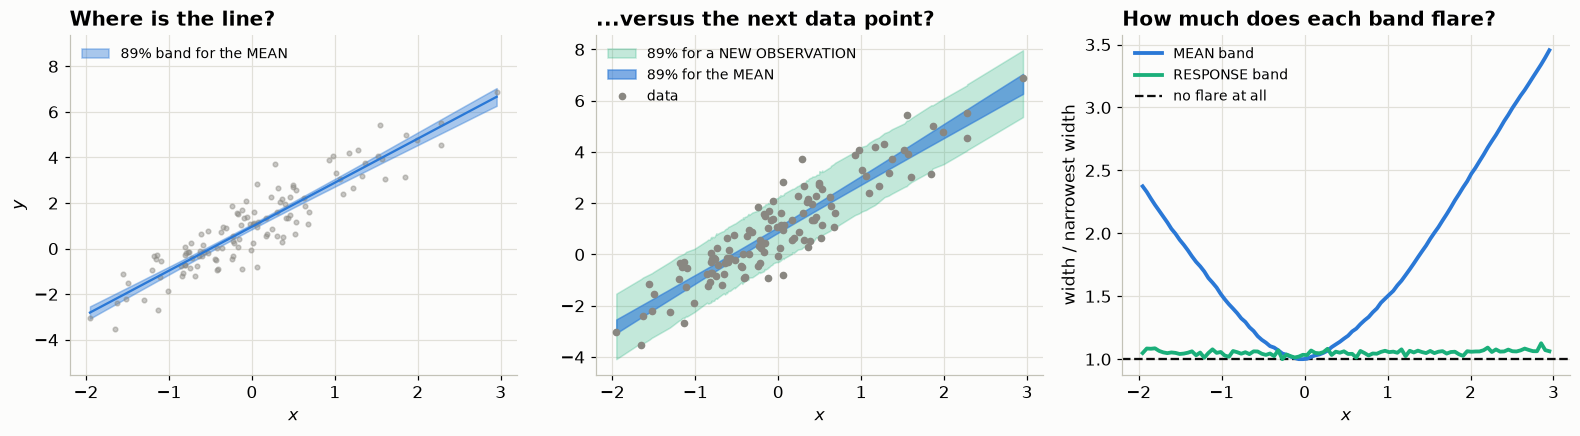

In [30]:
# MEAN band: push the coefficient draws through the line. No noise anywhere.
ic_all = post_p["Intercept"].values.ravel()
sl_all = post_p["x"].values.ravel()
sd_all = post_p["sigma"].values.ravel()
mu_draws = ic_all[:, None] + sl_all[:, None] * xs[None, :]      # (draws, grid)
mu_lo, mu_mid, mu_hi = np.percentile(mu_draws, [5.5, 50, 94.5], axis=0)

# RESPONSE band, built BY HAND on the same grid so the two are comparable:
# take each posterior line and scatter a point around it with that draw's sigma.
# This is literally the definition, and doing it explicitly is the point.
rng_pp = np.random.default_rng(RANDOM_SEED)
y_new_draws = mu_draws + rng_pp.normal(0.0, 1.0, mu_draws.shape) * sd_all[:, None]
y_lo, y_hi = np.percentile(y_new_draws, [5.5, 94.5], axis=0)

# ...and the same thing from PyMC, at the x values the model was BUILT with.
with regression:
    ppc_reg = pm.sample_posterior_predictive(idata_pymc, random_seed=RANDOM_SEED,
                                             progressbar=False)

y_pred = ppc_reg["posterior_predictive"].dataset["y"].values   # (chain, draw, obs)
y_pred = y_pred.reshape(-1, y_pred.shape[-1])
lo, mid, hi = np.percentile(y_pred, [5.5, 50, 94.5], axis=0)
order = np.argsort(x)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.1))

# (1) The mean band alone, zoomed so the hourglass is actually visible.
ax = axes[0]
ax.fill_between(xs, mu_lo, mu_hi, color=S.PRIMARY, alpha=0.40,
                label="89% band for the MEAN")
ax.plot(xs, mu_mid, color=S.PRIMARY, lw=1.5)
ax.plot(x, y, "o", color=S.MUTED, ms=3, ls="none", alpha=0.45, zorder=1)
pad = 3.5 * (mu_hi - mu_lo).max()
ax.set(title="Where is the line?", xlabel="$x$", ylabel="$y$",
       ylim=(mu_mid.min() - pad, mu_mid.max() + pad))
ax.legend(fontsize=9, loc="upper left")

# (2) Both bands, to scale.
ax = axes[1]
ax.fill_between(x[order], lo[order], hi[order], color=S.ALT, alpha=0.25,
                label="89% for a NEW OBSERVATION")
ax.fill_between(xs, mu_lo, mu_hi, color=S.PRIMARY, alpha=0.60,
                label="89% for the MEAN")
ax.plot(x, y, "o", color=S.MUTED, ms=4, ls="none", label="data", zorder=3)
ax.set(title="...versus the next data point?", xlabel="$x$")
ax.legend(fontsize=9, loc="upper left")

# (3) The diagnostic: each band's width RELATIVE TO ITS OWN NARROWEST POINT.
#     Both start at 1.0, so the comparison is about shape, not scale.
ax = axes[2]
w_mu = mu_hi - mu_lo
w_y = y_hi - y_lo
ax.plot(xs, w_mu / w_mu.min(), color=S.PRIMARY, lw=2.5, label="MEAN band")
ax.plot(xs, w_y / w_y.min(), color=S.ALT, lw=2.5, label="RESPONSE band")
S.truth_line(ax, 1.0, label="no flare at all")
ax.set(title="How much does each band flare?", xlabel="$x$",
       ylabel="width / narrowest width")
ax.legend(fontsize=9)
fig.tight_layout()

### Why the wide band looks like it has constant width

It is worth checking that suspicion with numbers rather than eyes. The mean
band is narrowest at the centre of the $x$ range and flares at the extremes —
the classic hourglass, because tilting the line about its centre moves the
ends far more than the middle. The response band inherits that same hourglass,
but adds $\sigma^2$ to the variance, and here $\sigma \approx 0.8$ **dwarfs**
the coefficient uncertainty. So it is not flat — it is an hourglass swamped by
a constant.

In [31]:
centre = np.argmin(np.abs(xs))                 # grid point nearest x = 0
edge = -1                                      # the largest x

mean_w = mu_hi - mu_lo
resp_w = y_hi - y_lo                           # both on the same grid now

print(f"{'':22s} {'at x ~ 0':>10s} {'at x = max':>12s} {'ratio':>8s}")
print(f"{'mean band width':22s} {mean_w[centre]:10.3f} {mean_w[edge]:12.3f}"
      f" {mean_w[edge] / mean_w[centre]:8.2f}")
print(f"{'response band width':22s} {resp_w[centre]:10.3f} {resp_w[edge]:12.3f}"
      f" {resp_w[edge] / resp_w[centre]:8.2f}")

# Sanity check: our hand-built response band and PyMC's should agree, since
# they are the same definition. Compare at the observed x, where PyMC has one.
pymc_w = np.interp(x[order], xs, resp_w)
print(f"\nhand-built vs pm.sample_posterior_predictive band width: "
      f"max gap {np.abs(pymc_w - (hi - lo)[order]).max():.3f}")

# The variance decomposition, at both ends. Standard deviations add IN
# QUADRATURE, which is the whole reason the flare gets flattened.
sigma_hat = post_p["sigma"].values.mean()
print(f"\nsigma = {sigma_hat:.3f}")
print(f"\n{'':10s} {'sd of mean':>11s} {'total sd':>10s}   decomposition")
for label, j in [("at x ~ 0", centre), ("at x = max", -1)]:
    sd_mu = mu_draws[:, j].std()
    total = np.sqrt(sd_mu**2 + sigma_hat**2)
    print(f"{label:10s} {sd_mu:11.3f} {total:10.3f}   "
          f"sqrt({sd_mu:.3f}^2 + {sigma_hat:.3f}^2)")

sd_c, sd_e = mu_draws[:, centre].std(), mu_draws[:, -1].std()
print(f"\nthe mean's sd grows {sd_e / sd_c:.2f}x from centre to edge,")
print(f"but the total sd grows only "
      f"{np.sqrt(sd_e**2 + sigma_hat**2) / np.sqrt(sd_c**2 + sigma_hat**2):.2f}x")
print(f"-> at the centre, noise is "
      f"{sigma_hat**2 / (sd_c**2 + sigma_hat**2):.1%} of the total variance")

                         at x ~ 0   at x = max    ratio
mean band width             0.225        0.778     3.45
response band width         2.470        2.538     1.03

hand-built vs pm.sample_posterior_predictive band width: max gap 0.124

sigma = 0.775

            sd of mean   total sd   decomposition
at x ~ 0         0.072      0.779   sqrt(0.072^2 + 0.775^2)
at x = max       0.243      0.812   sqrt(0.243^2 + 0.775^2)

the mean's sd grows 3.39x from centre to edge,
but the total sd grows only 1.04x
-> at the centre, noise is 99.2% of the total variance


There it is — the third panel is the whole answer. The mean band's width more
than triples from centre to edge; the response band's sits flat on 1.0.

The mechanism is worth stating exactly, because it is easy to get half-right.
The response band **does** inherit the flare, but **standard deviations combine
in quadrature**, not additively:

$$
\operatorname{sd}\!\left(y^{\text{new}} \mid x\right)
= \sqrt{\operatorname{sd}(\mu(x))^2 + \sigma^2}.
$$

When $\sigma$ is much the larger term, adding a small quantity under a square
root barely moves the result — which is why the ratios printed above differ so
sharply while describing the same underlying flare. The flare is not absent, it
is ** suppressed**. So the suspicion that the wide band has
constant width is a good one, and the resolution is that it very nearly does,
for a reason.

(The small wobble on the green curve is Monte Carlo noise in the percentiles,
not structure. More draws would flatten it further.)

This is a fact about **this** dataset, not about regression. With 120 points
the mean is pinned down tightly. Re-run the fit with `N_DATA = 8` and the two
terms become comparable, at which point the hourglass is plainly visible in
the response band too — a worthwhile thing to try.

<details class="sbi-key" open>
<summary>🔑 <b>Ask which band you actually want</b></summary>

"Where is the effect?" is a question about the **mean** — use the narrow band.
"What value would I see on the next trial?" is a question about a **new
observation** — use the wide one. Reporting the mean band as though it were a
prediction interval is a common and consequential error: it makes a model look
far more certain about future data than it is.

Neither is "the" posterior predictive, so the phrase alone is ambiguous. Say
which one you mean, and check what your library returns by default — most
`predict` functions give you the response band, but not all of them do.

</details>

One limitation is worth noticing now, because it sets up the next section.
`sample_posterior_predictive` predicts at the $x$ values the model was
**built with**. To predict at *new* $x$ — the usual reason you fit a
regression — you have to restructure the model so the covariate is a
`pm.Data` container and then swap it with `pm.set_data`. Doable, but it is
extra machinery, and you have to plan for it in advance.

## 5. The same regression, in bambi

<img src="../../images/logos/bambi-logo.png" alt="bambi logo"
     style="display:block; margin:0.5rem auto 1.5rem auto; width:240px">

For standard regression structures, writing the graph out by hand is
repetitive. **bambi** takes a formula and builds the PyMC model for you.

It is also the layer HSSM is built on, so the formula syntax you learn here is
the syntax you will use tomorrow morning to put a regression on a drift rate.

In [32]:
model_bmb = bmb.Model("y ~ 1 + x", data)
print(model_bmb)

       Formula: y ~ 1 + x
        Family: gaussian
          Link: mu = identity
  Observations: 120
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.9544, sigma: 4.7928)
            x ~ Normal(mu: 0.0, sigma: 5.2536)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 1.9171)


Notice what `print(model)` gives you: the formula, the family, the link, and
**every prior bambi chose on your behalf**. Those priors are not arbitrary —
they are scaled to your data — but they are choices, and you should look at
them.

In [33]:
idata_bmb = model_bmb.fit(draws=1000,
                          tune=1000,
                          chains=4,
                          cores=1,
                          progressbar=False,
                          random_seed=RANDOM_SEED
                          )
print(az.summary(idata_bmb, kind="stats").to_string())

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [sigma, Intercept, x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


           mean     sd eti89_lb eti89_ub
sigma      0.78  0.052      0.7     0.86
Intercept  0.96  0.071     0.85      1.1
x           1.9  0.078      1.8      2.1


### There is no magic — look at the generated model

The best way to believe bambi is to make it show you the PyMC model it built.

In [34]:
print(type(model_bmb.backend.model))
for rv in model_bmb.backend.model.basic_RVs:
    print("  ", rv.name)

<class 'pymc.model.core.Model'>
   sigma
   Intercept
   x
   y


That is the same graph you wrote by hand in section 4, with bambi's own
naming. Compare the two side by side:

In [35]:
comparison = pd.DataFrame({
    "hand-written PyMC": az.summary(idata_pymc, kind="stats")["mean"],
    "bambi": az.summary(idata_bmb, kind="stats")["mean"].reindex(
        ["Intercept", "x", "sigma"]),
})
print(comparison.to_string())
print("\n(Small differences are Monte Carlo noise plus bambi's data-scaled priors.)")

          hand-written PyMC bambi
Intercept              0.96  0.96
x                       1.9   1.9
sigma                  0.78  0.78

(Small differences are Monte Carlo noise plus bambi's data-scaled priors.)


### Where bambi actually earns its keep

The formula is the least interesting part. What bambi buys you is everything
*after* the fit — and in particular, prediction at covariate values the model
never saw, which took extra planning in raw PyMC.

**bambi names the two bands in its API**, which is genuinely helpful — the
distinction we just had to construct by hand is a keyword argument here:

| `kind=` | what you get | which band |
|---|---|---|
| `"response_params"` *(default)* | `posterior["mu"]` — the linear predictor | the **mean** band |
| `"response"` | `posterior_predictive["y"]` — simulated observations | the **response** band |

Note the default is `"response_params"`. Ask for `"response"` when you want
what `pm.sample_posterior_predictive` gives you.

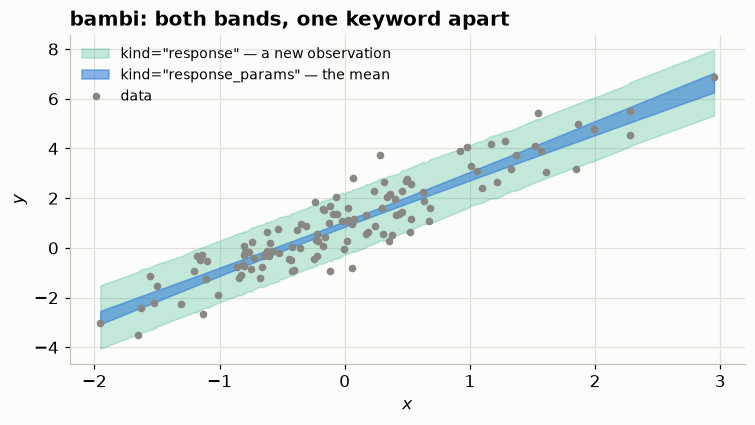

In [36]:
# Both kinds, one line each.
model_bmb.predict(idata_bmb, kind="response_params", inplace=True)  # -> posterior["mu"]
model_bmb.predict(idata_bmb, kind="response", inplace=True)         # -> posterior_predictive["y"]

mu_b = idata_bmb["posterior"].dataset["mu"].values
mu_b = mu_b.reshape(-1, mu_b.shape[-1])
mu_lo_b, mu_hi_b = np.percentile(mu_b, [5.5, 94.5], axis=0)

pp = idata_bmb["posterior_predictive"].dataset["y"].values
pp = pp.reshape(-1, pp.shape[-1])
lo_b, mid_b, hi_b = np.percentile(pp, [5.5, 50, 94.5], axis=0)

order = np.argsort(data["x"].to_numpy())
xo = data["x"].to_numpy()[order]

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(xo, lo_b[order], hi_b[order], color=S.ALT, alpha=0.25,
                label='kind="response" — a new observation')
ax.fill_between(xo, mu_lo_b[order], mu_hi_b[order], color=S.PRIMARY, alpha=0.55,
                label='kind="response_params" — the mean')
ax.plot(data["x"], data["y"], "o", color=S.MUTED, ms=4, ls="none",
        label="data", zorder=3)
ax.set(title="bambi: both bands, one keyword apart", xlabel="$x$", ylabel="$y$")
ax.legend(fontsize=9, loc="upper left")
fig.tight_layout()

### Predicting out of sample.
Hand `predict` a new dataframe and it does the rest 
— no `pm.Data`, no `set_data`, no rebuilding the model.

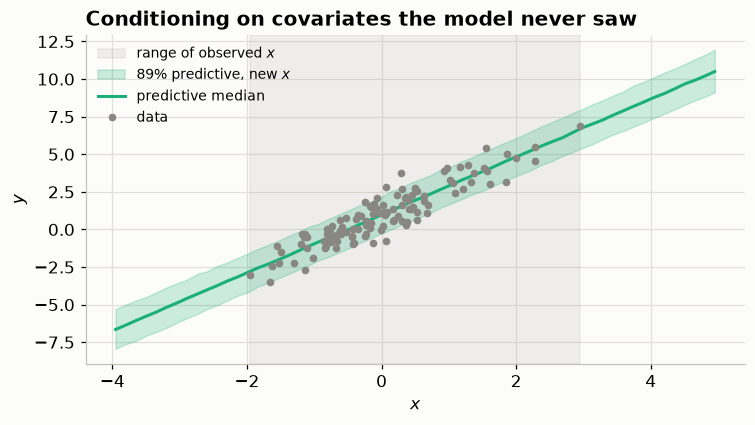

In [37]:
# Deliberately extrapolate beyond the observed range of x.
new_x = pd.DataFrame({"x": np.linspace(data["x"].min() - 2, data["x"].max() + 2, 60)})
oos = model_bmb.predict(idata_bmb, kind="response", data=new_x, inplace=False)

pp_new = oos["posterior_predictive"].dataset["y"].values
pp_new = pp_new.reshape(-1, pp_new.shape[-1])
lo_n, mid_n, hi_n = np.percentile(pp_new, [5.5, 50, 94.5], axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.axvspan(data["x"].min(), data["x"].max(), color=S.MUTED, alpha=0.12,
           label="range of observed $x$")
ax.fill_between(new_x["x"], lo_n, hi_n, color=S.ALT, alpha=0.22,
                label="89% predictive, new $x$")
ax.plot(new_x["x"], mid_n, color=S.ALT, lw=2, label="predictive median")
ax.plot(data["x"], data["y"], "o", color=S.MUTED, ms=4, ls="none", label="data")
ax.set(title="Conditioning on covariates the model never saw",
       xlabel="$x$", ylabel="$y$")
ax.legend(fontsize=9)
fig.tight_layout()

<details class="sbi-tip">
<summary>💡 <b>This is the argument for bambi in one picture</b></summary>

`model.predict(idata, data=new_x)` — that is the whole out-of-sample story.
For any model whose structure bambi can express, you get prediction,
marginalisation over covariates, and the `bmb.interpret` tools (predictions,
comparisons, slopes) without writing them.

</details>

Note the band widens outside the shaded region. The model is extrapolating,
and it says so. It is still *only* honest about the uncertainty it knows
about — a straight line assumed to keep being straight. Widening error bars
are not a warrant for trusting an extrapolation.

### When to use which

| | write it in PyMC | write it in bambi |
|---|---|---|
| standard GLM / mixed model | works, verbose | one line |
| custom likelihood (e.g. a DDM) | the only option | no |
| non-standard structure | the only option | no |
| you want explicit control of every prior | yes | possible, but you are fighting it |

bambi is a front end, not a different engine. Everything you learn about PyMC
sampling, diagnostics and `DataTree` applies unchanged — which is why we did
it in this order.

### Exercise 3

Add a grouping variable to the simulated data (say 5 groups with different
intercepts), then write the bambi formula for a model with a **random
intercept per group**. Fit it and check that the group-level parameters
appear in the posterior.

<details>
<summary>Solution</summary>

```python
g = rng.integers(0, 5, n)
offsets = rng.normal(0, 1.5, 5)
data2 = data.assign(group=[f"g{i}" for i in g],
                    y=data["y"] + offsets[g])

m = bmb.Model("y ~ x + (1|group)", data2)
print(m)
idata2 = m.fit(draws=1000, tune=1000, chains=4, cores=1,
               progressbar=False, random_seed=RANDOM_SEED)
print(az.summary(idata2, kind="stats").to_string())
```

`(1|group)` is a random intercept. You should see `1|group` entries plus a
`1|group_sigma` — the population spread of the group intercepts. That
`_sigma` is the parameter whose geometry we spend all of Day 3, 11:00 on.

</details>

## 6. Optional: the `do` operator

*(Skip if we are short on time — nothing later depends on it. But it is the
mechanism behind every "dataset whose truth we know" in this course, so it is
worth ten minutes at some point.)*

PyMC can **intervene** on a model, not just condition on it. `pm.do` replaces
a variable with a fixed value and **cuts the arrows coming into it**. That is
a different operation from observing the same value, and the difference is the
whole of causal inference in one idea.

It has a second use that matters more for us day to day, and we come back to
it at the end of this section: **`do` is how you turn a fitted model back into
a generator with parameters you choose**, which is exactly what a parameter
recovery study needs.

To see it you need a model where something upstream exists. Take a chain:

$$
z \sim \text{Normal}(0, 1), \qquad
x \mid z \sim \text{Normal}(z,\ 0.5), \qquad
y \mid x \sim \text{Normal}(x,\ 0.5).
$$

Now ask what we learn about $z$ in two scenarios: we **observe** $x = 2$,
versus we **set** $x = 2$ ourselves.

In [38]:
with pm.Model() as chain:
    z = pm.Normal("z", 0.0, 1.0)
    x_var = pm.Normal("x_var", mu=z, sigma=0.5)
    pm.Normal("y_var", mu=x_var, sigma=0.5)

# Both functions return a NEW model; `chain` itself is untouched.
observed = pm.observe(chain, {chain["x_var"]: 2.0})    # condition
intervened = pm.do(chain, {chain["x_var"]: 2.0})       # intervene

### Look at what each one did to the graph

This is the clearest way to see the difference, and it is structural rather
than statistical — you can read the answer off the picture before running a
single sampler.

In [39]:
from IPython.display import HTML, display


def _graph_svg(model):
    return pm.model_to_graphviz(model).pipe(format="svg").decode()


try:
    display(HTML(
        '<div style="display:flex; gap:3rem; align-items:flex-start; '
        'flex-wrap:wrap">'
        f'<div><b>original model</b><br>{_graph_svg(chain)}</div>'
        f'<div><b>pm.observe(x_var = 2)</b><br>{_graph_svg(observed)}</div>'
        f'<div><b>pm.do(x_var = 2)</b><br>{_graph_svg(intervened)}</div>'
        '</div>'))
except Exception as exc:                      # graphviz needs the `dot` BINARY
    print(f"graphviz unavailable ({type(exc).__name__}); mermaid instead\n")
    for name, m in [("ORIGINAL", chain), ("OBSERVE", observed), ("DO", intervened)]:
        print(f"--- {name} ---")
        print(pm.model_to_mermaid(m), "\n")

Read the three graphs left to right:

- **Original.** `z → x_var → y_var`, all three open (unobserved).
- **`pm.observe`.** `x_var` is now **shaded** — it is data. But the arrow
  `z → x_var` is **still there**. That edge is the channel evidence travels
  along, and it runs in both directions: knowing `x_var` tells you about `z`.
- **`pm.do`.** `x_var` is no longer a random variable at all; it has become a
  constant, and **the arrow from `z` is gone**. `z` is now disconnected from
  everything downstream.

That missing arrow is the entire content of the do-operator. Once it is cut,
no amount of sampling can send information from `x_var` back to `z` — not
because we told it not to, but because there is no path.

Now confirm that the graphs predicted the numbers:

In [40]:
# (a) OBSERVE x = 2  -> evidence flows backwards along the surviving edge
with observed:
    idata_obs = pm.sample(draws=1000, tune=1000, chains=2, cores=1,
                          nuts_sampler="pymc", progressbar=False,
                          random_seed=RANDOM_SEED)

# (b) DO x = 2  -> the z -> x arrow is cut, so z keeps its prior
with intervened:
    idata_do = pm.sample_prior_predictive(draws=2000, random_seed=RANDOM_SEED)

z_obs = idata_obs.posterior.dataset["z"].values.ravel()
z_do = idata_do["prior"].dataset["z"].values.ravel()
print(f"E[z | observe x=2] = {z_obs.mean():+.3f}")
print(f"E[z | do(x=2)]     = {z_do.mean():+.3f}   (prior mean is 0)")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [z, y_var]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling: [y_var, z]


E[z | observe x=2] = +1.582
E[z | do(x=2)]     = +0.004   (prior mean is 0)


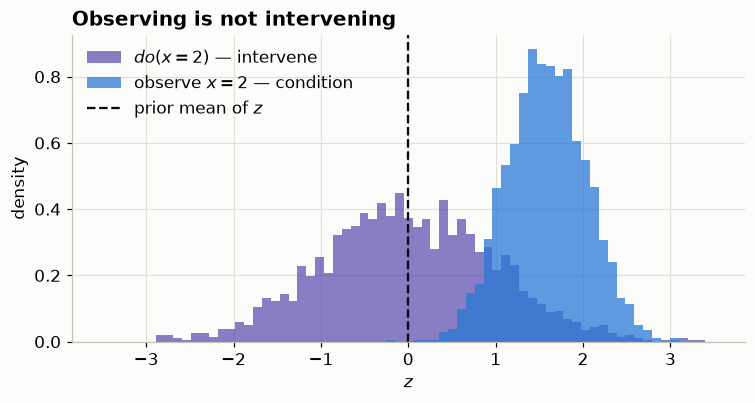

In [41]:
fig, ax = plt.subplots(figsize=(7, 3.8))
bins = np.linspace(-3.5, 3.5, 70)
ax.hist(z_do, bins=bins, density=True, color=S.NAIVE, alpha=0.65,
        label="$do(x=2)$ — intervene")
ax.hist(z_obs, bins=bins, density=True, color=S.PRIMARY, alpha=0.75,
        label="observe $x=2$ — condition")
S.truth_line(ax, 0.0, axis="x", label="prior mean of $z$")
ax.set(title="Observing is not intervening", xlabel="$z$", ylabel="density")
ax.legend()
fig.tight_layout()

**Observing** $x = 2$ is evidence: $x$ is downstream of $z$, so a high $x$
makes a high $z$ more plausible and the posterior shifts. **Intervening** —
reaching in and setting $x$ — destroys that inferential link, because the
value no longer came from $z$. $z$ keeps its prior.

<details class="sbi-note">
<summary>📝 <b>Why a modelling library has this at all</b></summary>

Once you can express interventions, a fitted model can answer "what would
happen if we *changed* this?" rather than only "what tends to go with what?".
`pm.do` and `pm.observe` return **new models**, leaving the original
untouched, so you can ask several such questions off one fit. HSSM exposes the
same idea as `model.sample_do(...)` — you will see it on Day 3.

</details>

### The use you will actually reach for: parameter recovery

Causal language aside, here is the everyday reason a cognitive modeller wants
`pm.do`. **A model you can fit is also a model you can generate from** — and
`do` is the switch between the two.

Pin every free parameter to a value you chose, draw from what remains, and you
have a dataset whose true parameters you know *exactly*. Fit that dataset with
the same model and you can ask the only question that really validates an
analysis pipeline:

> If the data really did come from this model, would I get the right answer back?

This is **parameter recovery**, and it is worth doing before any real dataset
is touched. It catches an unidentifiable design, a coding error, a prior that
is quietly doing the work, and a sampler that has not converged — none of
which announce themselves on real data, where you never learn the truth.

The whole loop, on the model from section 2:

In [42]:
# 1. GENERATE — intervene on the model to fix mu and sigma at chosen values.
TRUE_PARAMS = {"mu": 4.2, "sigma": 0.8}

with pm.Model() as recovery_model:
    mu_r = pm.Normal("mu", 0.0, 10.0)
    sigma_r = pm.HalfNormal("sigma", 5.0)
    pm.Normal("y", mu=mu_r, sigma=sigma_r, shape=200)

generator = pm.do(recovery_model,
                  {recovery_model["mu"]: TRUE_PARAMS["mu"],
                   recovery_model["sigma"]: TRUE_PARAMS["sigma"]})
with generator:
    synthetic = pm.sample_prior_predictive(draws=1, random_seed=RANDOM_SEED)
y_synth = synthetic["prior"].dataset["y"].values.ravel()

print(f"generated {y_synth.size} observations "
      f"| sample mean {y_synth.mean():.3f}, sample sd {y_synth.std():.3f}")

Sampling: [y]


generated 200 observations | sample mean 4.207, sample sd 0.726


In [43]:
# 2. RECOVER — hand the synthetic data back to the SAME model and fit it.
with pm.Model() as fit_model:
    mu_f = pm.Normal("mu", 0.0, 10.0)
    sigma_f = pm.HalfNormal("sigma", 5.0)
    pm.Normal("y", mu=mu_f, sigma=sigma_f, observed=y_synth)
    idata_rec = pm.sample(draws=1000, tune=1000, chains=4, cores=1,
                          nuts_sampler="pymc", progressbar=False,
                          random_seed=RANDOM_SEED)

# 3. CHECK — does the posterior cover the values we generated with?
print(az.summary(idata_rec, kind="stats", ci_prob=0.89).to_string(), "\n")

# Compute the interval from the DRAWS, not by reading it back out of the
# summary table: az.summary returns formatted STRINGS rounded to a couple of
# significant figures, so `4.2` comes back as the string "4".
post_rec = idata_rec.posterior.dataset
for name, truth in TRUE_PARAMS.items():
    lo, hi = np.percentile(post_rec[name].values, [5.5, 94.5])
    print(f"  {name:6s} true {truth:5.2f}   89% interval [{lo:5.2f}, {hi:5.2f}]   "
          f"{'COVERED' if lo <= truth <= hi else '*** MISSED ***'}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [mu, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


       mean     sd eti89_lb eti89_ub
mu      4.2  0.054      4.1      4.3
sigma  0.73  0.037     0.68     0.79 

  mu     true  4.20   89% interval [ 4.12,  4.29]   COVERED
  sigma  true  0.80   89% interval [ 0.68,  0.79]   *** MISSED ***


Look closely at that result before drawing a conclusion from it: `mu` is
covered and **`sigma` is not** — its 89% interval stops just short of 0.80.

Nothing is broken. The 200 numbers we generated happen to have a sample sd of
about 0.73, and the posterior has correctly recovered *the data it was given*.
With $n = 200$ the sampling sd of a sample sd is roughly
$\sigma/\sqrt{2n} \approx 0.04$, so landing 0.07 low is an ordinary draw.

Which exposes the real lesson: **one recovery run tells you almost nothing.**
An 89% interval is *supposed* to miss about 11% of the time. A single run that
covers is weak evidence, and a single run that misses is not a bug report.

The honest version repeats the whole loop over many simulated datasets and
asks whether the intervals cover **at their nominal rate**:

In [44]:
def recover_once(seed, n=200):
    """Generate one dataset from TRUE_PARAMS, refit, return the 89% intervals."""
    with pm.Model() as gen:
        pm.Normal("mu", 0.0, 10.0)
        pm.HalfNormal("sigma", 5.0)
        pm.Normal("y", mu=gen["mu"], sigma=gen["sigma"], shape=n)

    with pm.do(gen, {gen["mu"]: TRUE_PARAMS["mu"],
                     gen["sigma"]: TRUE_PARAMS["sigma"]}):
        ys = (pm.sample_prior_predictive(draws=1, random_seed=seed)
              ["prior"].dataset["y"].values.ravel())

    with pm.Model() as fit:
        pm.Normal("mu", 0.0, 10.0)
        pm.HalfNormal("sigma", 5.0)
        pm.Normal("y", mu=fit["mu"], sigma=fit["sigma"], observed=ys)
        idt = pm.sample(600, tune=600, chains=2, cores=1, nuts_sampler="pymc",
                        progressbar=False, random_seed=seed)

    return {k: np.percentile(idt.posterior.dataset[k].values, [5.5, 94.5])
            for k in TRUE_PARAMS}


N_REPS = 40
hits = {k: 0 for k in TRUE_PARAMS}
for seed in range(N_REPS):
    for k, (lo, hi) in recover_once(seed).items():
        hits[k] += lo <= TRUE_PARAMS[k] <= hi

print(f"{N_REPS} simulated datasets, 89% intervals:\n")
for k, n_hit in hits.items():
    print(f"  {k:6s} covered {n_hit:2d}/{N_REPS} = {n_hit / N_REPS:.0%}   "
          f"(nominal 89%)")

Sampling: [y]


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu, sigma]


Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 0 seconds.


...

Sequential sampling (2 chains in 1 job)


NUTS: [mu, sigma]


Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


40 simulated datasets, 89% intervals:

  mu     covered 35/40 = 88%   (nominal 89%)
  sigma  covered 38/40 = 95%   (nominal 89%)


Both land near 89%, which is the result you want: the intervals are
**calibrated**. Had one come back at 60%, the model would be overconfident and
no single fit from it could be trusted — and you would never have found that
out from one run, or from any amount of real data.

<details class="sbi-note">
<summary>📝 <b>Read the coverage numbers with their own error bars</b></summary>

With 40 replications, the standard error on a coverage estimate near 0.89 is
about $\sqrt{0.89 \times 0.11 / 40} \approx 5\%$. So anything from roughly 79%
to 99% is consistent with a correctly calibrated interval, and you should not
read a difference of one or two hits as a finding. Serious calibration work
uses hundreds of replications — or **simulation-based calibration**, which
checks the whole rank distribution rather than one interval, and which this
summer school covers in its own right.

</details>

Note what `pm.do` bought us: **one model definition served as both the
generator and the estimator.** Without it you would write the simulation twice
— once as numpy, once as a PyMC model — and the two versions drift apart. The
bug that then survives is the worst kind, because your recovery study is
validating the wrong thing and passing.

<details class="sbi-tip" open>
<summary>💡 <b>Where this goes for cognitive models</b></summary>

Everything above generalises directly, and the rest of the course leans on it:

- **At 14:30 today** you fit a DDM to data simulated from known parameters,
  and check recovery cell by cell. **At 15:00** you meet a design where
  recovery *fails* — drift and non-decision time trade off — and the only
  reason you can tell is that the truth is known.
- **Tomorrow at 09:30**, HSSM's `model.sample_do(...)` is this exact operation
  with a nicer signature: pin `v`, `a`, `z`, `t` (or the coefficients of a
  regression on them) and draw a dataset. The DDM dataset in that session is
  built precisely this way.
- For a real study, run recovery across a **grid** of plausible parameters
  rather than one point. A model can recover beautifully at the centre of
  parameter space and fall apart at the edges, and the edge is often where
  your participants are.

The habit to take away: **before fitting a new model to real data, fit it to
fake data from itself.** It is cheap, and it is the only setting in which you
ever get to grade your own answer.

</details>

## What to take away

<details class="sbi-tip" open>
<summary>💡 <b>The things that matter</b></summary>

1. **A distribution is used two ways.** `pm.Normal.dist(...)` is a value you
   can draw from and take `logp` of. `pm.Normal("name", ...)` inside a model
   context is a **node in a graph**, and the name is how you get results back.
2. **You are building a graph, behind the scenes.** PyTensor allows you to compile
   the graph into multiple backend frameworks.
3. **Bambi** is a front-end to PyMC that makes specifying hierarchical mixed-effects
   regressions much easier. It is, in turn, the primary backend for HSSM.
4. **Name your dimensions.** `coords` + `dims` cost one dictionary and give you
   `mu[high]` instead of `mu[2]`, everywhere downstream — including in the
   labels HSSM hands back tomorrow.
5. **`pm.do` turns a model into its own data generator.** Pin the parameters,
   simulate, refit, check the truth is covered. Do this before any real data.

</details>

**Next:** We stop assuming the sampler works, and start looking at when it
does not.